# Storing Smart City Insights in a Smarter Database: A GridDB + EPA Data Story

## Introduction

Did you know that people living in walkable neighborhoods are healthier and less prone to cardiometabolic diseases? A study published in the popular scientific journal 'Nature' mentioned that walkability significantly improves health outcomes; with residents in walkable areas being less prone to chronic diseases. So, what makes a neighborhood walkable, and how does it impact our physical and mental well-being? Let’s delve deeper into this topic.
[Source: Nature, https://www.nature.com/articles/s41598-025-94192-x]

We use GridDB for this analysis. GridDB bridges the gap between SQL and NoSQL by providing users with a SQL interface that supports SQL-like syntax. In other words, when a user writes a SQL query, GridDB takes that query and translates it into NoSQL operations to scan the data. The key steps in SQL to NoSQL conversion are shown in the diagram below. Refer to the <a href = "https://griddb.org/docs-en/manuals/GridDB_SQL_Reference.html"> GridDB SQL Reference </a> to learn more about the SQL Interface. 

For this analysis, we use the Smart Location Database published by the U.S Environmental Protection Agency (EPA).The dataset has features that describe built environment characteristics across the U.S., like walkability, population density, land use mix, street connectivity, and employment accessibility for several census block groups. It generally helps measure how “walkable,” “compact,” or “transit-connected” different neighborhoods are.

## Importing Libraries

In [434]:
from IPython.display import Image, display, HTML
import pandas as pd
import base64
import requests
import os
import json
import http.client
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

## About the Dataset

The data can be downloaded from <a href = "https://catalog.data.gov/dataset/walkability-index8/resource/356986ec-b9ab-4fdf-8838-7262a08502e3"> data.gov</a>. The URL provided in this page points to the '.csv' data file hosted on the EPA Commons website and available for public consumption. This URL is used in the section 'Loading the Dataset'. Below is a screenshot of the same. 

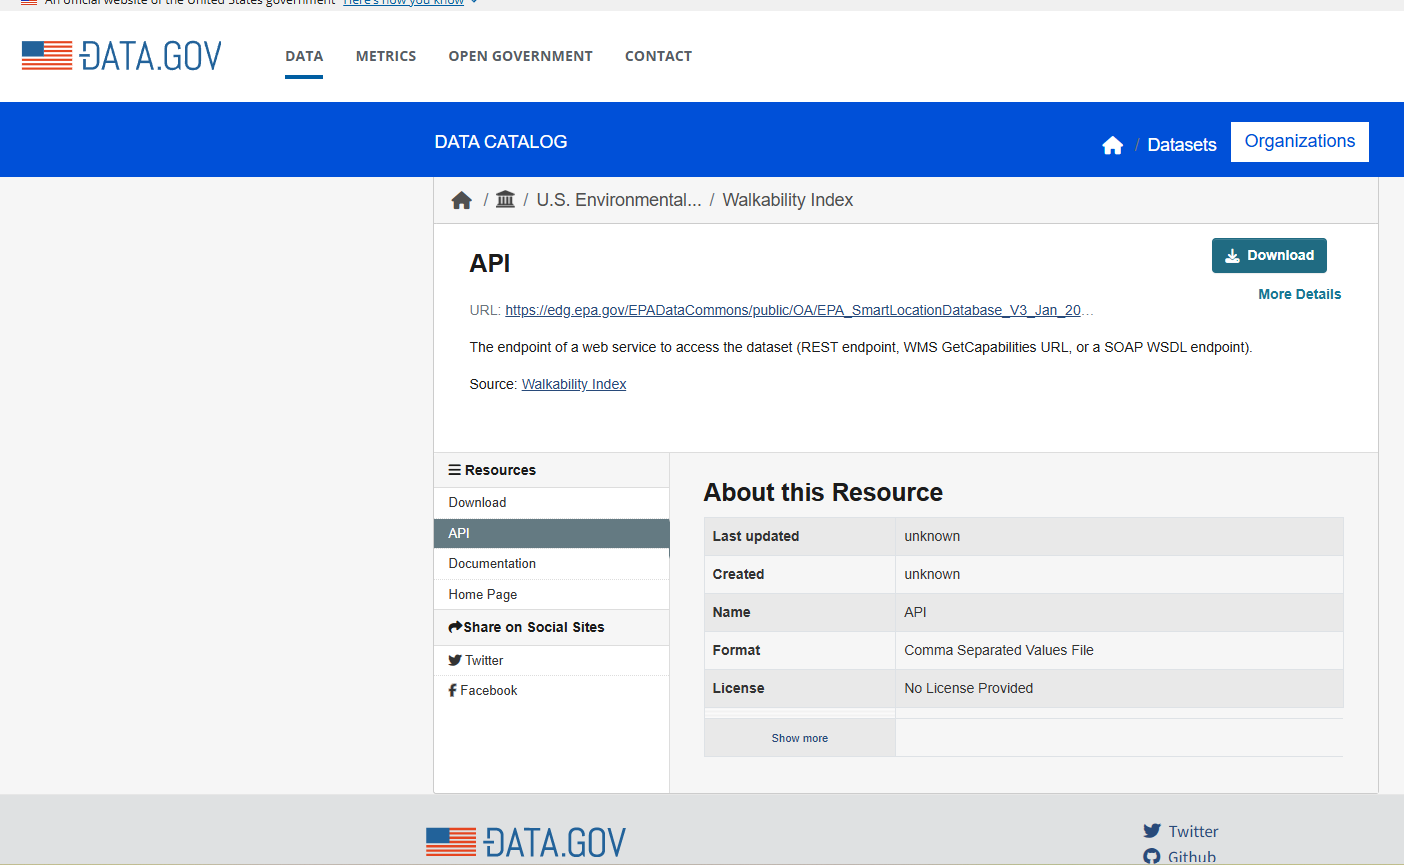

In [135]:
Image(filename='Dataset_Download.png',width=800, height=600)

## Loading the Dataset

In [ ]:
# URL of the CSV file
url = "https://edg.epa.gov/EPADataCommons/public/OA/EPA_SmartLocationDatabase_V3_Jan_2021_Final.csv"

# Load into a DataFrame
walkability_data = pd.read_csv(url)

## Subsetting the Data

In [ ]:
# Step 1: Select necessary columns
columns_to_keep = [
    'OBJECTID', 'GEOID10', 'STATEFP', 'COUNTYFP', 'TRACTCE', 'CBSA',
    'D5DRI', 'D5DE', 'D5DEI', 'NatWalkInd', 'Shape_Length', 'Shape_Area'
]

df_subset = walkability_data[columns_to_keep]

# Filter for specific states
states_to_filter = [6, 48, 51]

walkability_subset = df_subset[df_subset['STATEFP'].isin(states_to_filter)]

# Filter out any rows with NaN or Infinite values in 'NatWalkInd'
walkability_subset = walkability_subset[~walkability_subset['NatWalkInd'].isin([float('inf'), -float('inf')])].dropna(subset=['NatWalkInd'])

# Drop rows with NaN values in any column
walkability_subset = walkability_subset.dropna()

# Filter by walkability score (e.g., NatWalkInd > 50)
walkability_subset = walkability_subset[walkability_subset['NatWalkInd'] > 14.0]


## Creating an Additional Dataset for State Mapping


In [ ]:
# Data for the state_mapping container (all U.S. states)
state_mapping_data = [
    {"STATEFP": "01", "StateName": "Alabama"},
    {"STATEFP": "02", "StateName": "Alaska"},
    {"STATEFP": "04", "StateName": "Arizona"},
    {"STATEFP": "05", "StateName": "Arkansas"},
    {"STATEFP": "06", "StateName": "California"},
    {"STATEFP": "08", "StateName": "Colorado"},
    {"STATEFP": "09", "StateName": "Connecticut"},
    {"STATEFP": "10", "StateName": "Delaware"},
    {"STATEFP": "11", "StateName": "District of Columbia"},
    {"STATEFP": "12", "StateName": "Florida"},
    {"STATEFP": "13", "StateName": "Georgia"},
    {"STATEFP": "15", "StateName": "Hawaii"},
    {"STATEFP": "16", "StateName": "Idaho"},
    {"STATEFP": "17", "StateName": "Illinois"},
    {"STATEFP": "18", "StateName": "Indiana"},
    {"STATEFP": "19", "StateName": "Iowa"},
    {"STATEFP": "20", "StateName": "Kansas"},
    {"STATEFP": "21", "StateName": "Kentucky"},
    {"STATEFP": "22", "StateName": "Louisiana"},
    {"STATEFP": "23", "StateName": "Maine"},
    {"STATEFP": "24", "StateName": "Maryland"},
    {"STATEFP": "25", "StateName": "Massachusetts"},
    {"STATEFP": "26", "StateName": "Michigan"},
    {"STATEFP": "27", "StateName": "Minnesota"},
    {"STATEFP": "28", "StateName": "Mississippi"},
    {"STATEFP": "29", "StateName": "Missouri"},
    {"STATEFP": "30", "StateName": "Montana"},
    {"STATEFP": "31", "StateName": "Nebraska"},
    {"STATEFP": "32", "StateName": "Nevada"},
    {"STATEFP": "33", "StateName": "New Hampshire"},
    {"STATEFP": "34", "StateName": "New Jersey"},
    {"STATEFP": "35", "StateName": "New Mexico"},
    {"STATEFP": "36", "StateName": "New York"},
    {"STATEFP": "37", "StateName": "North Carolina"},
    {"STATEFP": "38", "StateName": "North Dakota"},
    {"STATEFP": "39", "StateName": "Ohio"},
    {"STATEFP": "40", "StateName": "Oklahoma"},
    {"STATEFP": "41", "StateName": "Oregon"},
    {"STATEFP": "42", "StateName": "Pennsylvania"},
    {"STATEFP": "44", "StateName": "Rhode Island"},
    {"STATEFP": "45", "StateName": "South Carolina"},
    {"STATEFP": "46", "StateName": "South Dakota"},
    {"STATEFP": "47", "StateName": "Tennessee"},
    {"STATEFP": "48", "StateName": "Texas"},
    {"STATEFP": "49", "StateName": "Utah"},
    {"STATEFP": "50", "StateName": "Vermont"},
    {"STATEFP": "51", "StateName": "Virginia"},
    {"STATEFP": "53", "StateName": "Washington"},
    {"STATEFP": "54", "StateName": "West Virginia"},
    {"STATEFP": "55", "StateName": "Wisconsin"},
    {"STATEFP": "56", "StateName": "Wyoming"},
    {"STATEFP": "60", "StateName": "American Samoa"},
    {"STATEFP": "66", "StateName": "Guam"},
    {"STATEFP": "69", "StateName": "Northern Mariana Islands"},
    {"STATEFP": "72", "StateName": "Puerto Rico"},
    {"STATEFP": "74", "StateName": "U.S. Virgin Islands"},
    {"STATEFP": "78", "StateName": "Federated States of Micronesia"},
    {"STATEFP": "82", "StateName": "Palau"}
]

# Convert the list of dictionaries into a DataFrame
state_mapping_df = pd.DataFrame(state_mapping_data)

## Explanation of Walkability Data Columns

In [ ]:
html_code = """
<table border="1">
  <thead>
    <tr>
      <th>Column Name</th>
      <th>Description</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>OBJECTID</td>
      <td>A unique identifier for each row/record (usually auto-generated by GIS software like ArcGIS).</td>
    </tr>
    <tr>
      <td>GEOID10</td>
      <td>2010 Census Tract identifier — a unique geographic code for a census tract.</td>
    </tr>
    <tr>
      <td>STATEFP</td>
      <td>State FIPS (Federal Information Processing Standards) code — uniquely identifies U.S. states.</td>
    </tr>
    <tr>
      <td>COUNTYFP</td>
      <td>County FIPS code — identifies counties within states.</td>
    </tr>
    <tr>
      <td>TRACTCE</td>
      <td>Census Tract Code — identifies individual census tracts within a county.</td>
    </tr>
    <tr>
      <td>CBSA</td>
      <td>Core-Based Statistical Area code — classifies urban areas (e.g., metros or micropolitan areas).</td>
    </tr>
    <tr>
      <td>D5DRI</td>
      <td>Distance to Retail Index — measures how far residents are from retail destinations.</td>
    </tr>
    <tr>
      <td>D5DE</td>
      <td>Diversity of Employment — an index measuring job diversity in a given area.</td>
    </tr>
    <tr>
      <td>D5DEI</td>
      <td>Employment Entropy Index — a statistical measure of employment mix (entropy means diversity).</td>
    </tr>
    <tr>
      <td>NatWalkInd</td>
      <td>National Walkability Index — score from 0 to 100 estimating how walkable an area is.</td>
    </tr>
    <tr>
      <td>Shape_Length</td>
      <td>Length of the geographic feature’s shape (used in GIS, often in meters).</td>
    </tr>
    <tr>
      <td>Shape_Area</td>
      <td>Area of the geographic shape (used in GIS, often in square meters or feet).</td>
    </tr>
  </tbody>
</table>
"""

display(HTML(html_code))

Column Name,Description
OBJECTID,A unique identifier for each row/record (usually auto-generated by GIS software like ArcGIS).
GEOID10,2010 Census Tract identifier — a unique geographic code for a census tract.
STATEFP,State FIPS (Federal Information Processing Standards) code — uniquely identifies U.S. states.
COUNTYFP,County FIPS code — identifies counties within states.
TRACTCE,Census Tract Code — identifies individual census tracts within a county.
CBSA,"Core-Based Statistical Area code — classifies urban areas (e.g., metros or micropolitan areas)."
D5DRI,Distance to Retail Index — measures how far residents are from retail destinations.
D5DE,Diversity of Employment — an index measuring job diversity in a given area.
D5DEI,Employment Entropy Index — a statistical measure of employment mix (entropy means diversity).
NatWalkInd,National Walkability Index — score from 0 to 100 estimating how walkable an area is.


Further details are available in the official EPA website - https://www.epa.gov/system/files/documents/2023-10/epa_sld_3.0_technicaldocumentationuserguide_may2021_0.pdf

## Connecting to GridDB

In [ ]:
# Replace with your actual GridDB connection details
username = "XXXXXX" 
password =   "XXXXXXX"
credentials = f"{username}:{password}"
encoded_credentials = base64.b64encode(credentials.encode()).decode()
print(f"Encoded credentials: Basic {encoded_credentials}")

Encoded credentials: Basic TTAxa3dXMTRjdC1zdWJoYTpUaGF0aHB1cnVzaGFheWExMjMj


In [ ]:
#Construct an object to hold the request headers (ensure that you replace the XXX placeholder with the correct value that matches the credentials for your GridDB instance)

header_obj = {
    "Authorization": f"Basic {encoded_credentials}",  # Add encoded credentials here
    "Content-Type": "application/json",  # Optional; depends on API requirements
    "charset": "UTF-8",
    "User-Agent":"PostmanRuntime/7.29.0"
}

#Construct the base URL based on your GridDB cluster you'd like to connect to (ensure that you replace the placeholders in the URL below with the correct values that correspond to your GridDB instance)
#'https://[host]:[port]/griddb/v2/[clustername]/dbs/[database_name]'
base_url = 'https://[host]:[port]/griddb/v2/[clustername]/dbs/[database_name]'

## Generating Container Structures for use in GridDB

### Functions to generate the container structures

In [9]:
def map_dtype_to_griddb(dtype):
    """
    Maps Pandas data types to GridDB data types.
    """
    if pd.api.types.is_integer_dtype(dtype):
        return "INTEGER"
    elif pd.api.types.is_float_dtype(dtype):
        return "DOUBLE"
    elif pd.api.types.is_bool_dtype(dtype):
        return "BOOL"
    elif pd.api.types.is_datetime64_any_dtype(dtype):
        return "LONG"  # GridDB stores timestamps as LONG
    else:
        return "STRING"

def generate_griddb_data_obj(df, container_name="MyContainer", container_type="COLLECTION", rowkey=False):
    """
    Generates a GridDB container data object for API request.
    """
    columns = []
    for col in df.columns:
        griddb_type = map_dtype_to_griddb(df[col].dtype)
        columns.append({"name": col, "type": griddb_type})
    
    data_obj = {
        "container_name": container_name,
        "container_type": container_type,
        "rowkey": rowkey,
        "columns": columns
    }
    
    return data_obj

## Creating Containers in GridDB

In [65]:
data_obj = generate_griddb_data_obj(walkability_subset, container_name="walkability_data")

#Set up the GridDB WebAPI URL
url = base_url + 'containers'

#Invoke the GridDB WebAPI with the headers and the request body
x = requests.post(url, json = data_obj, headers = header_obj)

In [182]:
data_obj_state_mapping = generate_griddb_data_obj(state_mapping_df, container_name="state_mapping_data")

#Set up the GridDB WebAPI URL
url = base_url + 'containers'

#Invoke the GridDB WebAPI with the headers and the request body
x = requests.post(url, json = data_obj_state_mapping, headers = header_obj)

## Row-Registration (Loading the Containers)

Row Registration in GridDB is analogous to inserting data in relational SQL databases. Refer to the <a href = "https://docs.griddb.net/architecture/data-model/"> GridDB Data Model </a> to learn more about row registration and to know how GridDB processes transactions.

In [66]:
# Parse the JSON string into a Python list of dictionaries
request_body_walkability_data = walkability_subset.to_json(orient='values')

In [67]:
#Setup the URL to be used to invoke the GridDB WebAPI to register rows in the container created previously
url = base_url + 'containers/walkability_data/rows'

#Invoke the GridDB WebAPI using the request constructed
x = requests.put(url, data=request_body_walkability_data, headers=header_obj)

In [194]:
# Parse the JSON string into a Python list of dictionaries
request_body_state_mapping = state_mapping_df.to_json(orient='values')

In [195]:
#Setup the URL to be used to invoke the GridDB WebAPI to register rows in the container created previously
url = base_url + 'containers/state_mapping_data/rows'

#Invoke the GridDB WebAPI using the request constructed
x = requests.put(url, data=request_body_state_mapping, headers=header_obj)

## Analysis using GridDB SQL

### Top 10 Metro Areas with High Walkability but Low Transit Access

GridDB supports type casting similar to explicit casting in relational SQL databases. It also supports standard aggregation operations like AVG, COUNT, and so on. Refer to <a href = "https://griddb.org/docs-en/manuals/GridDB_SQL_Reference.html#aggregate-functions"> this resource </a> to learn more.

In [117]:
sql_query1 = ("""
                SELECT CAST(CBSA AS INT) AS CBSA, AVG(NatWalkInd) AS "Average Walk Index"
                FROM walkability_data
                GROUP BY CBSA
                ORDER BY 2 DESC
                LIMIT 10;
""")

In [118]:
#Setup the URL to be used to invoke the GridDB WebAPI to retrieve data from the container
url = base_url + 'sql'

# Construct the request body
request_body = json.dumps([
    {
        "type": "sql-select",
        "stmt": sql_query1
    }
])

# Disable HTTP debugging
http.client.HTTPConnection.debuglevel = 0

#Invoke the GridDB WebAPI
data_req1 = requests.post(url, data=request_body, headers=header_obj)

#Process the response received and construct a Pandas dataframe with the data from the response
myJson = data_req1.json()
high_wkblty_low_trnst_access = pd.DataFrame(myJson[0]["results"], columns=[myJson[0]["columns"][0]["name"], myJson[0]["columns"][1]["name"]])

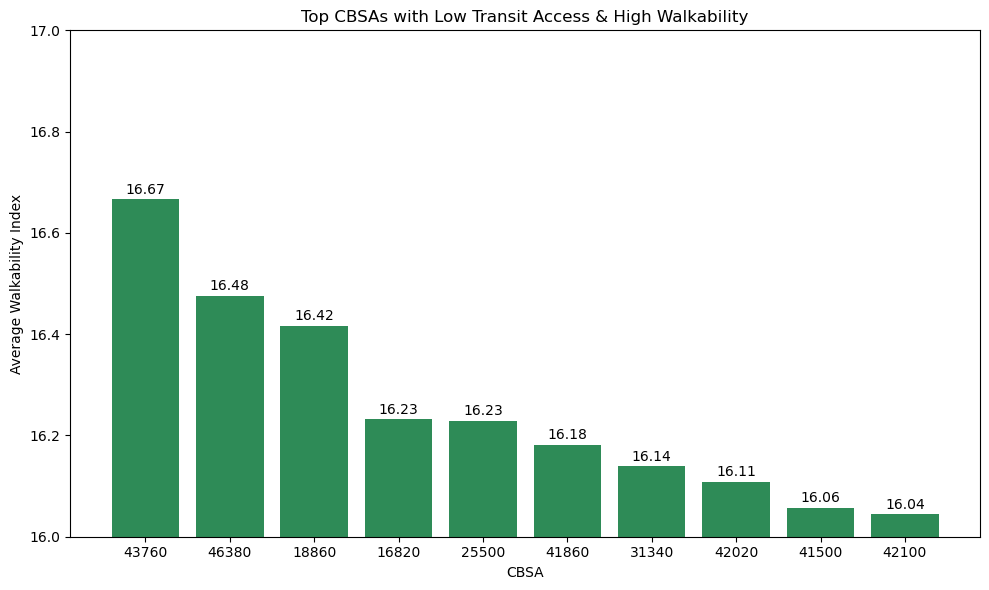

In [132]:
# Plot
plt.figure(figsize=(10, 6))
bars = plt.bar(high_wkblty_low_trnst_access["CBSA"].astype(str), high_wkblty_low_trnst_access["Average Walk Index"], color='seagreen')

# Set a tighter y-axis range to enhance differences
plt.ylim(16, 17)

# Add labels and title
plt.xlabel("CBSA")
plt.ylabel("Average Walkability Index")
plt.title("Top CBSAs with Low Transit Access & High Walkability")

# Add value labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, round(yval, 2), ha='center', va='bottom')

plt.tight_layout()
plt.show()


<b> Insight(s): </b> The top CBSA having the highest walkability index is that of 43760 (New York-Newark-Jersey City, NY-NJ-PA). Being a large and highly urbanized metropolitan area in the U.S., it is not surprising that it has one of the highest walkability scores.  

### Average Walkability Index by State

GridDB supports Inner Join, Left Outer Join and Cross Join operations. Refer to <a href = "https://griddb.org/docs-en/manuals/GridDB_SQL_Reference.html#join"> this resource </a> to learn more. 

In [428]:
sql_query2 = ("""
                SELECT sm.StateName, ROUND(AVG(wd.NatWalkInd),3) AS "Average Walkability Index"
                FROM walkability_data wd
                JOIN state_mapping_data sm ON wd.STATEFP = CAST(sm.STATEFP AS INT)
                GROUP BY sm.StateName
                ORDER BY 2 DESC;

""")

In [429]:
#Setup the URL to be used to invoke the GridDB WebAPI to retrieve data from the container
url = base_url + 'sql'

# Construct the request body
request_body = json.dumps([
    {
        "type": "sql-select",
        "stmt": sql_query2
    }
])

# Disable HTTP debugging
http.client.HTTPConnection.debuglevel = 0

#Invoke the GridDB WebAPI
data_req2 = requests.post(url, data=request_body, headers=header_obj)

#Process the response received and construct a Pandas dataframe with the data from the response
myJson = data_req2.json()
walkability_by_state = pd.DataFrame(myJson[0]["results"], columns=[myJson[0]["columns"][0]["name"], myJson[0]["columns"][1]["name"]])

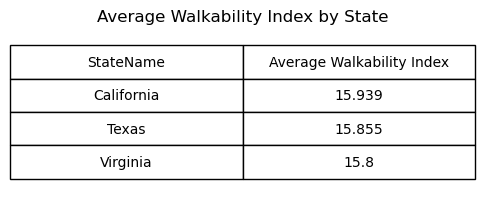

In [430]:
# Create a figure and axis
fig, ax = plt.subplots(figsize=(6, 2))
ax.axis('off')  # Hide axes

# Create the table
table = ax.table(
    cellText=walkability_by_state.values,
    colLabels=walkability_by_state.columns,
    cellLoc='center',
    loc='center'
)

table.scale(1, 2)  # Optional: scale the table (width, height)
table.auto_set_font_size(False)
table.set_fontsize(10)

plt.title("Average Walkability Index by State", fontsize=12, pad=10)
plt.show()

<b> Insight(s): </b> <ul> <li> California has the highest Average Walkability Index at 15.939, suggesting that the state tends to have more walkable cities and areas overall. </li> <li> This could be attributed to urban centers like San Francisco or Los Angeles, which have historically worked towards improving pedestrian infrastructure, walkable neighborhoods, and public transportation systems.</li> <li> Texas and Virginia have relatively similar Average Walkability Index values of 15.855 and 15.800, respectively. The slight difference between them indicates that their walkability scores are close, though Texas' urban areas (like Austin or Dallas) are often known for suburban sprawl, while Virginia’s urban areas (like Washington D.C. suburbs) may have more focus on walkability in specific areas. </li></ul>


## Top 5 Counties in terms of Walkability Index

In [298]:
sql_query3 = ("""
            SELECT wd.STATEFP, wd.COUNTYFP, MAX(wd.NatWalkInd) AS "Highest Walkability Index"
            FROM walkability_data wd
            JOIN state_mapping_data sm
            ON wd.STATEFP = CAST(sm.STATEFP AS INT)
            WHERE sm.StateName IN ('California', 'Texas', 'Virginia')
            GROUP BY wd.STATEFP, wd.COUNTYFP
            ORDER BY "Highest Walkability Index" DESC
            LIMIT 2;
""")


In [299]:
#Setup the URL to be used to invoke the GridDB WebAPI to retrieve data from the container
url = base_url + 'sql'

# Construct the request body
request_body = json.dumps([
    {
        "type": "sql-select",
        "stmt": sql_query3
    }
])

# Disable HTTP debugging
http.client.HTTPConnection.debuglevel = 0

#Invoke the GridDB WebAPI
data_req3 = requests.post(url, data=request_body, headers=header_obj)

#Process the response received and construct a Pandas dataframe with the data from the response
myJson = data_req3.json()
walkability_by_counties = pd.DataFrame(myJson[0]["results"], columns=[myJson[0]["columns"][0]["name"], myJson[0]["columns"][1]["name"], myJson[0]["columns"][2]["name"]])

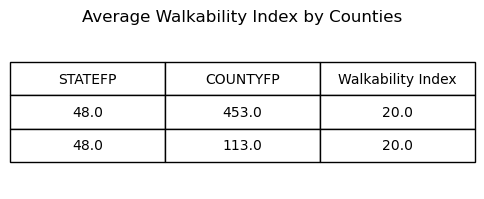

In [ ]:
fig, ax = plt.subplots(figsize=(6, 2))
ax.axis('off')  # Hide axes

# Create the table without the 'County' column (since we're not mapping COUNTYFP to county names)
table = ax.table(
    cellText=walkability_by_counties[['STATEFP', 'COUNTYFP', 'Highest Walkability Index']].values,
    colLabels=['STATEFP', 'COUNTYFP', 'Walkability Index'],
    cellLoc='center',
    loc='center'
)

# Scale the table (width, height)
table.scale(1, 2)  

# Set font size
table.auto_set_font_size(False)
table.set_fontsize(10)

# Add a title to the plot
plt.title("Average Walkability Index by Counties", fontsize=12, pad=10)

# Show the plot
plt.show()


<b>Insight(s): </b> 453 (Williamson County) and 113 (Dallas County) in Texas have the highest walkability index among the selected states. Williamson County is located in the Austin-Round Rock metro area, which is known for its walkable neighborhoods and urban planning initiatives. Dallas County, being part of the larger Dallas-Fort Worth metroplex, also has areas with high walkability scores, particularly in urban centers.

## Do Bigger Counties have a better Walkability Index?

In [348]:
sql_query4 = ("""
            SELECT STATEFP, COUNTYFP, AVG(NatWalkInd) AS "Avg_Walkability_Index", AVG(Shape_Length) AS "Avg_Shape_Length"
            FROM walkability_data
            WHERE STATEFP IN (6, 48, 51)
            GROUP BY STATEFP, COUNTYFP
            ORDER BY Avg_Shape_Length DESC
            LIMIT 20;
            """)

In [349]:
#Setup the URL to be used to invoke the GridDB WebAPI to retrieve data from the container
url = base_url + 'sql'

# Construct the request body
request_body = json.dumps([
    {
        "type": "sql-select",
        "stmt": sql_query4
    }
])

# Disable HTTP debugging
http.client.HTTPConnection.debuglevel = 0

#Invoke the GridDB WebAPI
data_req4 = requests.post(url, data=request_body, headers=header_obj)

#Process the response received and construct a Pandas dataframe with the data from the response
myJson = data_req4.json()
geographical_shape_walkability = pd.DataFrame(myJson[0]["results"], columns=[myJson[0]["columns"][0]["name"], myJson[0]["columns"][1]["name"], myJson[0]["columns"][2]["name"], myJson[0]["columns"][3]["name"]])

In [ ]:
# Assuming your dataframe is named df
fig = px.scatter(geographical_shape_walkability, x='Avg_Shape_Length', y='Avg_Walkability_Index',
                 labels={'Avg Shape Length': 'Average Shape Length', 
                         'Avg Walkability Index': 'Average Walkability Index'},
                 title="Relationship Between Walkability and Shape Length")
fig.show()

The scatter plot shows that there is a weak negative relationship between Avg Walkability Index and Avg Shape Length. As the Avg Shape Length increases, the Avg Walkability Index tends to decrease slightly.

In [351]:
# Assuming your dataframe is named df
corr_matrix = geographical_shape_walkability.corr()

# Display the correlation matrix
print(corr_matrix)

                        STATEFP  COUNTYFP  Avg_Walkability_Index  \
STATEFP                1.000000  0.550018              -0.421389   
COUNTYFP               0.550018  1.000000              -0.118743   
Avg_Walkability_Index -0.421389 -0.118743               1.000000   
Avg_Shape_Length       0.150326 -0.308945              -0.264991   

                       Avg_Shape_Length  
STATEFP                        0.150326  
COUNTYFP                      -0.308945  
Avg_Walkability_Index         -0.264991  
Avg_Shape_Length               1.000000  


<b> Insight(s): </b> Bigger counties with more extensive land areas or complex boundaries tend to have a slightly lower walkability index. Walkability in larger areas may be lower on average, but it doesn't mean that all large areas are unwalkable.

### Exploring the Relationship Between Geographical Size and Walkability in Select U.S. Counties

In [413]:
sql_query5 = ("""
            SELECT STATEFP, COUNTYFP, Avg_Walkability_Index, Avg_Shape_Length
            FROM (
                SELECT STATEFP, COUNTYFP, 
                AVG(NatWalkInd) AS Avg_Walkability_Index, 
                AVG(Shape_Length) AS Avg_Shape_Length
                FROM walkability_data
                WHERE STATEFP IN (6, 48, 51)
                GROUP BY STATEFP, COUNTYFP
            ) AS subquery
            WHERE Avg_Shape_Length > 3000.0
            ORDER BY Avg_Walkability_Index DESC
            LIMIT 10;

""")

In [ ]:
#Setup the URL to be used to invoke the GridDB WebAPI to retrieve data from the container
url = base_url + 'sql'

# Construct the request body
request_body = json.dumps([
    {
        "type": "sql-select",
        "stmt": sql_query5
    }
])

# Disable HTTP debugging
http.client.HTTPConnection.debuglevel = 0

#Invoke the GridDB WebAPI
data_req5 = requests.post(url, data=request_body, headers=header_obj)

#Process the response received and construct a Pandas dataframe with the data from the response
myJson = data_req5.json()
specific_county_walkability = pd.DataFrame(myJson[0]["results"], columns=[myJson[0]["columns"][0]["name"], myJson[0]["columns"][1]["name"], myJson[0]["columns"][2]["name"], myJson[0]["columns"][3]["name"]])

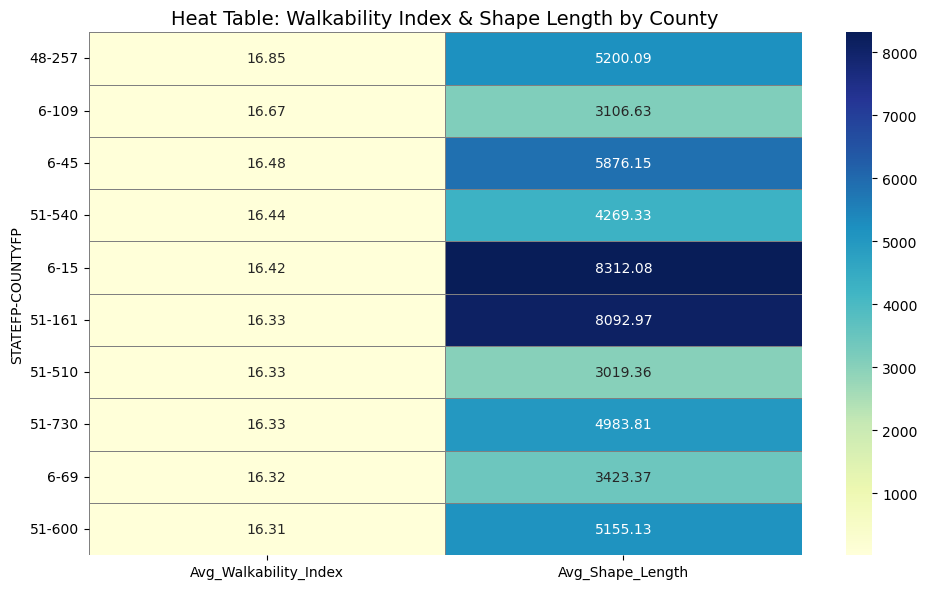

In [ ]:
specific_county_walkability.set_index(['STATEFP', 'COUNTYFP'], inplace=True)

plt.figure(figsize=(10, 6))
sns.heatmap(specific_county_walkability, annot=True, fmt=".2f", cmap="YlGnBu", linewidths=0.5, linecolor='gray')

plt.title("Heat Table: Walkability Index & Shape Length by County", fontsize=14)
plt.yticks(rotation=0)  # Keep labels horizontal
plt.tight_layout()
plt.show()

<ul> 
<li> Counties 6-15 (California) and 51-161 (Virginia) exhibit exceptionally large shape lengths—exceeding 8,000 meters. Such expansiveness can complicate infrastructure planning therey diluting walkability. This could be why these counties have not topped the list in terms of walkability. However, these counties are still fairly walkable as they have relatively high walkability indices. </li>
<li> County 48-257 (Texas) has the highest Walkability Index at 16.85, indicating that it is relatively pedestrian-friendly. </li>
<li> Multiple counties in Virginia have a consistent walkability index at 16.33; indicating that the urban planning is consistent in prioritizing walkability features throughout the state.</li> </ul>

## Concluding Remarks

In conclusion, assessing the walkability of a county can help improve living experiences. For this proof of concept, we leveraged GridDB to store and analyze the trimmed dataset, which enabled efficient data retrieval and complex queries despite the dataset's smaller scope. While this is just a starting point, it demonstrates how GridDB can effectively handle large datasets and facilitate analysis at scale. Check out <a href = "https://griddb.net/en/blog/griddb-cloud-quick-start-guide/"> GridDB Cloud's Quickstart Guide </a> to learn more.